# AOI-based Analysis of Fixation Data

```{admonition} Overview
This tutorial will introduce an AOI drawing tool, `AOIDrawer`, and showcase some basic AOI-based analyses you can do with PupEyes.
```

## Drawing AOIs

PupEyes includes an `AOIDrawer` that allows you to manually define AOIs. The defined AOIs will be saved as a `.json` file and can be used in other PupEyes functions.

In [1]:
from pupeyes import AOIDrawer

In [50]:
# path to image
background_img = 'assets/street1.jpg'

# Create and run the drawer
drawer = AOIDrawer(screen_dims=(1600, 1200), stimuli=background_img, stimuli_name='street1')
drawer.run()

Original size: (6231, 4154) Resized size: (1600, 1200)


The saved AOIs can be reloaded and used in other PupEyes functions. For example, let's load the saved AOIs and redraw them.

In [49]:
import json

# load AOIs
with open('assets/street1_aois.json', 'r') as f:
    aois = json.load(f)

`aois` is a Python dictionary that stores the vertices of each AOI.

In [34]:
print(aois)

{'cars': [[1070.6842105263154, 800.7969924812029], [1070.6842105263154, 830.1203007518797], [1104.5187969924807, 841.3984962406014], [1118.0526315789468, 857.1879699248119], [1140.6090225563905, 845.9097744360902], [1165.4210526315785, 848.1654135338345], [1167.676691729323, 861.6992481203007], [1194.7443609022553, 857.1879699248119], [1212.7894736842102, 845.9097744360902], [1217.300751879699, 886.5112781954887], [1246.6240601503755, 884.2556390977443], [1255.646616541353, 877.4887218045112], [1314.2932330827064, 879.7443609022556], [1384.2180451127815, 895.5338345864661], [1377.4511278195484, 789.5187969924812], [1341.3609022556386, 757.9398496240601], [1233.0902255639094, 760.1954887218044], [1215.0451127819545, 778.2406015037593], [1208.2781954887214, 775.9849624060149], [1149.6315789473679, 762.4511278195488], [1088.7293233082703, 764.7067669172932], [1081.9624060150372, 769.2180451127819]], 'lights': [[190.97742066347502, 171.46381578947367], [382.7067439717456, 171.4638157894736

Let's draw these AOIs using `draw_aois()` from PupEyes 

Original size: (6231, 4154) Resized size: (1600, 1200)


(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Areas of Interest (AOIs)'}>)

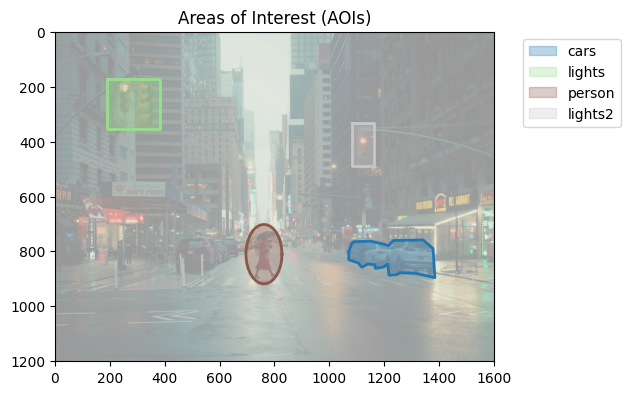

In [51]:
from pupeyes import draw_aois

# draw AOI
draw_aois(aois, screen_dims=(1600, 1200), background_img=background_img)

### Computing Basic AOI Measures

To illustrate how the defined AOIs can be used in subsequent analyses, we will do some simple AOI-based analysis: we will assign each fixation to an AOI and compute some basic AOI measures.

In [40]:
from pupeyes.aoi import get_fixation_aoi, compute_aoi_statistics
import numpy as np

# define some fixation positions and fixation durations
fixations = np.array([
    (50, 50, 200), # None
    (200, 250, 300), # lights
    (500, 250, 100), # None
    (750, 800, 350), # person
    (750, 800, 250), # person
    (750, 600, 100), # None
    (1100, 800, 450), # cars
    (1100, 400, 150), # lights2
    (1500, 400, 1000)] # None
                    )

# get the corresponding AOI for each fixation
get_fixation_aoi(x=fixations[:, 0], # x pos
                 y=fixations[:, 1], # y pos
                 aois=aois
                )

[None, 'lights', None, 'person', 'person', None, 'cars', 'lights2', None]

`compute_aoi_statistics()` allows you to compute basic AOI-based measures, given the x and y coordinates, AOIs, and fixation durations.

In [43]:
compute_aoi_statistics(
    x=fixations[:, 0], # x pos
    y=fixations[:, 1], # y pos
    aois=aois,
    durations=fixations[:, 2] # durations
)

{'outside': {'count': np.int64(4), 'total_duration': np.float64(1400.0)},
 'cars': {'count': np.int64(1), 'total_duration': np.float64(450.0)},
 'lights': {'count': np.int64(1), 'total_duration': np.float64(300.0)},
 'person': {'count': np.int64(2), 'total_duration': np.float64(600.0)},
 'lights2': {'count': np.int64(1), 'total_duration': np.float64(150.0)}}

```{tip}
You can supply your own AOIs to `draw_aoi()`, `get_fixation_aoi()`, and `compute_aoi_statistics()`.
```